<a href="https://colab.research.google.com/github/pollybond/MD-Data-Science/blob/master/%D0%9F%D1%80%D0%B5%D0%B4%D0%B8%D0%BA%D1%82%D0%B8%D0%B2%D0%BD%D0%B0%D1%8F_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D1%82%D0%B8%D0%BA%D0%B0_ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, r2_score
import pywt

In [4]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

# Загрузка данных
df = pd.read_csv(
    'retail_sales_mock_data.csv',
    parse_dates=['Date'],
    index_col='Date'
)

df = df.sort_index()
df

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0
2020-06-01,9131,1,0
2020-07-01,9089,0,0
2020-08-01,10300,0,0
2020-09-01,10464,0,0


In [5]:
# Целевая переменная
y = df['SalesAmount']

# Экзогенные переменные
exog_vars = ['Promotion', 'HolidayMonth']
X = df[exog_vars]

print(f"\nЦелевая переменная: '{y.name}'")
print(f"Экзогенные переменные: {exog_vars}")


Целевая переменная: 'SalesAmount'
Экзогенные переменные: ['Promotion', 'HolidayMonth']


In [6]:
def get_adaptive_params(series, default_period=7):
    """
    Адаптивный подбор параметров для временных рядов

    Returns:
        period: сезонный период (нечётное число >= 3)
        max_lags: максимальное количество лагов для ACF
        min_samples: минимальная длина для декомпозиции
    """
    n = len(series.dropna())

    period = default_period
    if period % 2 == 0:
        period += 1
    period = min(period, n // 2)
    period = max(period, 3)
    if period % 2 == 0:
        period += 1

    max_lags = min(20, n // 3)
    max_lags = max(max_lags, 5)
    min_samples = period * 2

    return period, max_lags, min_samples, n

period, max_lags, min_samples, n_obs = get_adaptive_params(y, default_period=7)
print(f"   Адаптивные параметры:")
print(f"   Наблюдений: {n_obs}")
print(f"   Сезонный период: {period} (нечётное, >= 3)")
print(f"   Макс. лагов для ACF: {max_lags}")
print(f"   Мин. для декомпозиции: {min_samples}")

   Адаптивные параметры:
   Наблюдений: 48
   Сезонный период: 7 (нечётное, >= 3)
   Макс. лагов для ACF: 16
   Мин. для декомпозиции: 14


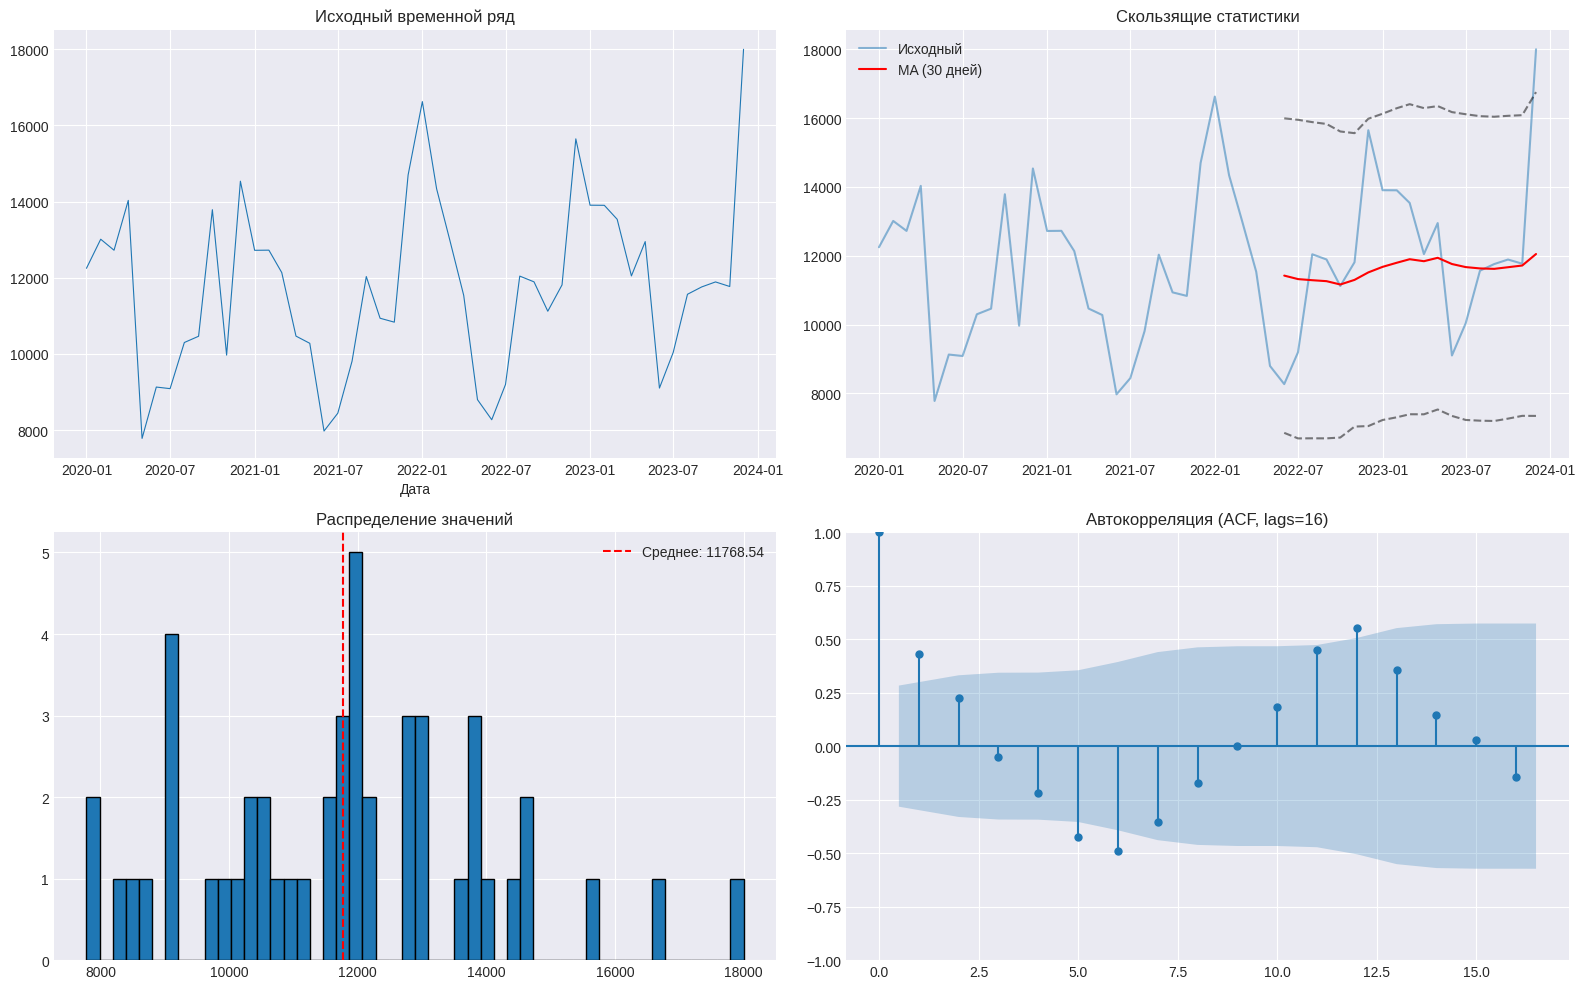

In [7]:
def plot_eda(series):
    """Базовая визуализация временного ряда"""
    series_clean = series.dropna().copy()
    max_lags = min(60, len(series_clean) // 3)
    max_lags = max(max_lags, 10)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Исходный ряд
    axes[0, 0].plot(series.index, series.values, linewidth=0.8)
    axes[0, 0].set_title('Исходный временной ряд')
    axes[0, 0].set_xlabel('Дата')
    axes[0, 0].grid(True)

    # Скользящее среднее и стандартное отклонение (окно 30 дней)
    rolling_mean = series.rolling(window=30).mean()
    rolling_std = series.rolling(window=30).std()
    axes[0, 1].plot(series.index, series.values, label='Исходный', alpha=0.5)
    axes[0, 1].plot(series.index, rolling_mean, label='MA (30 дней)', color='red')
    axes[0, 1].plot(series.index, rolling_mean + 2*rolling_std, 'k--', alpha=0.5)
    axes[0, 1].plot(series.index, rolling_mean - 2*rolling_std, 'k--', alpha=0.5)
    axes[0, 1].set_title('Скользящие статистики')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Гистограмма распределения
    axes[1, 0].hist(series.dropna(), bins=50, edgecolor='black')
    axes[1, 0].axvline(series.mean(), color='red', linestyle='--', label=f'Среднее: {series.mean():.2f}')
    axes[1, 0].set_title('Распределение значений')
    axes[1, 0].legend()
    axes[1, 0].grid(True, axis='y')

    # ACF
    try:
        plot_acf(series_clean.values, lags=max_lags, ax=axes[1, 1], alpha=0.05)
        axes[1, 1].set_title(f'Автокорреляция (ACF, lags={max_lags})')
    except Exception as e:
        print(f"⚠️ Ошибка при построении ACF: {e}")
        axes[1, 1].text(0.5, 0.5, 'ACF plot failed', ha='center', va='center')

    plt.tight_layout()
    plt.show()

plot_eda(y)

Декомпозиция: n=48, period=7, min_required=14


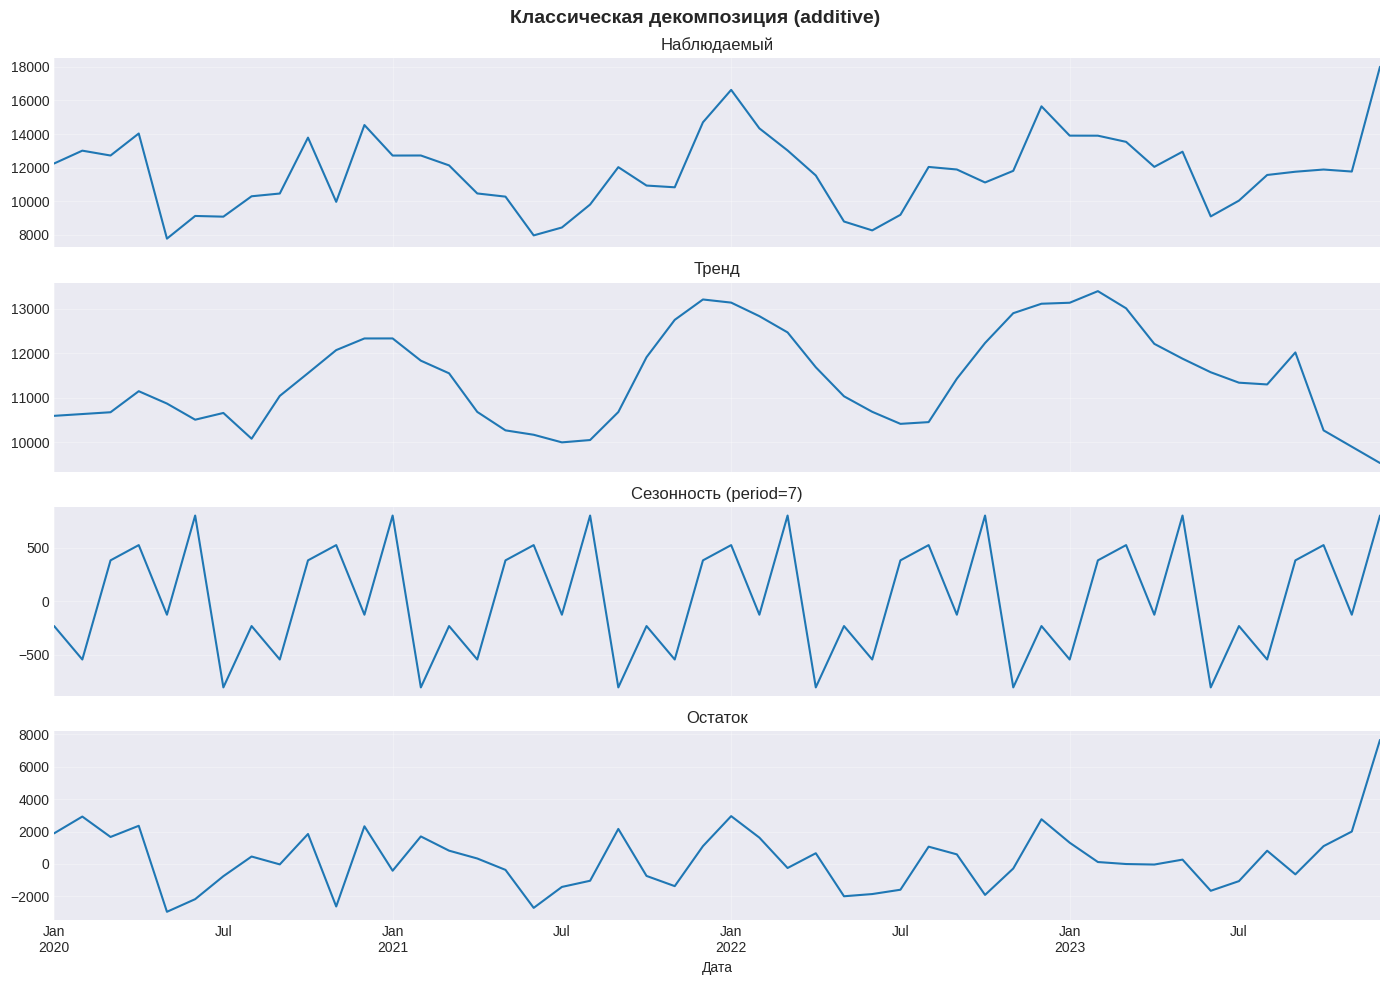

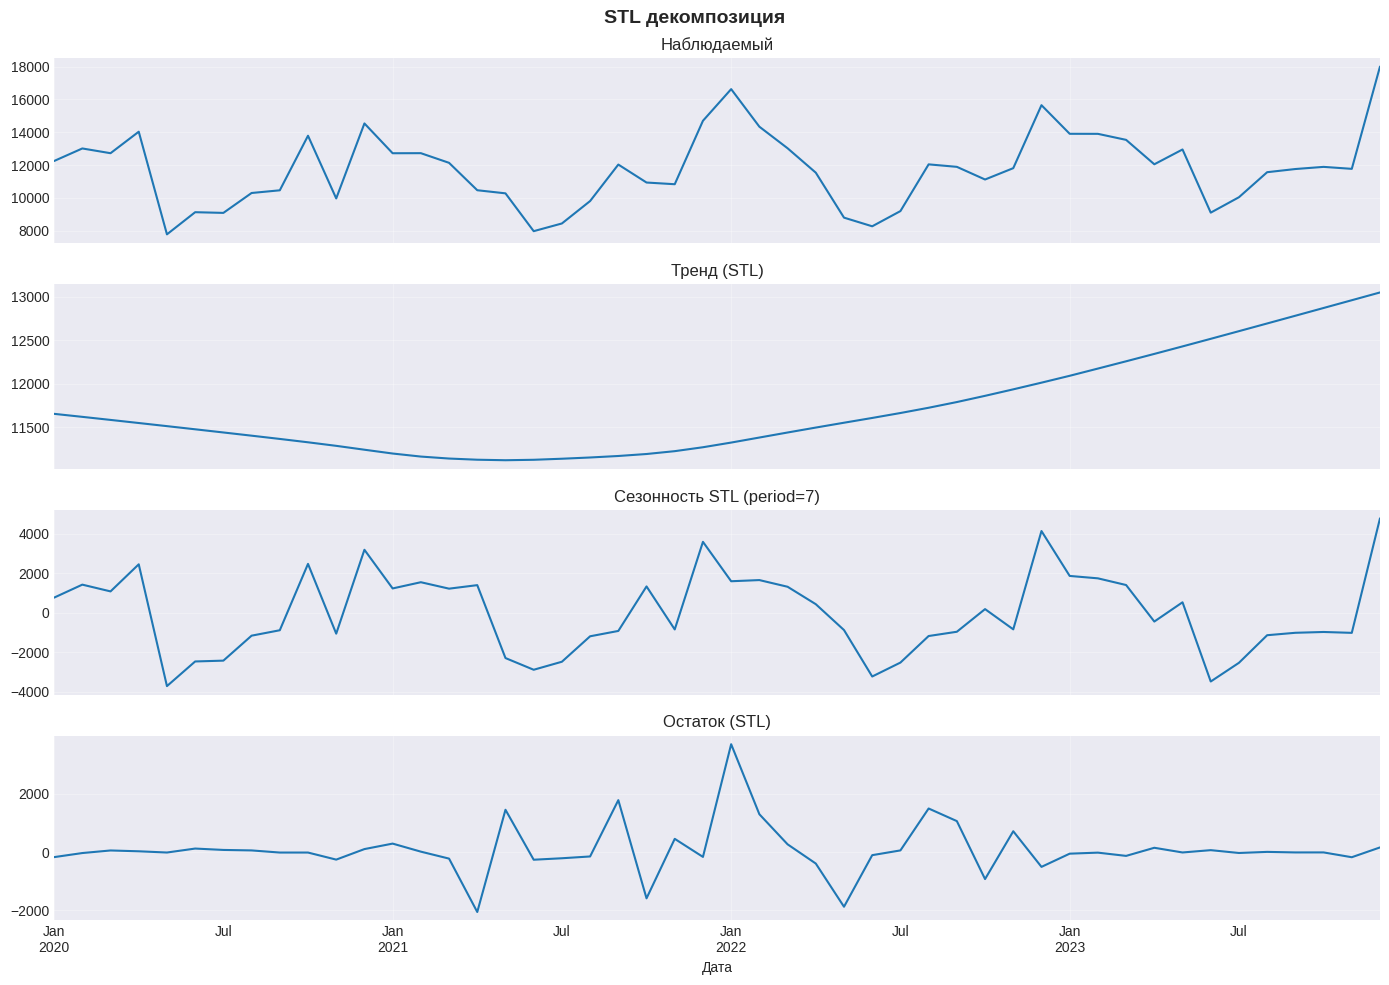

In [9]:
def decompose_adaptive(series, model='additive', default_period=7):
    """Адаптивная декомпозиция для малых выборок"""
    series_clean = series.dropna()
    n = len(series_clean)

    # Авто-подбор периода
    period, _, min_samples, _ = get_adaptive_params(series_clean, default_period)

    print(f"Декомпозиция: n={n}, period={period}, min_required={min_samples}")

    if n < min_samples:
        print(f"Предупреждение: {n} < {min_samples} — декомпозиция может быть неточной")
        print("Рекомендация: соберите больше данных или используйте упрощённый анализ")

    results = {}

    # Классическая декомпозиция
    try:
        result_classic = seasonal_decompose(
            series_clean,
            model=model,
            period=period,
            extrapolate_trend='freq'
        )
        results['classic'] = result_classic

        # Визуализация
        fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
        result_classic.observed.plot(ax=axes[0], title='Наблюдаемый')
        result_classic.trend.plot(ax=axes[1], title='Тренд')
        result_classic.seasonal.plot(ax=axes[2], title=f'Сезонность (period={period})')
        result_classic.resid.plot(ax=axes[3], title='Остаток')
        for ax in axes:
            ax.grid(True, alpha=0.3)
        axes[-1].set_xlabel('Дата')
        plt.suptitle(f'Классическая декомпозиция ({model})', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Классическая декомпозиция: {e}")
        results['classic'] = None

    # STL декомпозиция
    try:
        stl = STL(series_clean, seasonal=period, robust=True)
        result_stl = stl.fit()
        results['stl'] = result_stl

        fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
        result_stl.observed.plot(ax=axes[0], title='Наблюдаемый')
        result_stl.trend.plot(ax=axes[1], title='Тренд (STL)')
        result_stl.seasonal.plot(ax=axes[2], title=f'Сезонность STL (period={period})')
        result_stl.resid.plot(ax=axes[3], title='Остаток (STL)')
        for ax in axes:
            ax.grid(True, alpha=0.3)
        axes[-1].set_xlabel('Дата')
        plt.suptitle(f'STL декомпозиция', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"STL декомпозиция: {e}")
        results['stl'] = None

    return results

decomp_results = decompose_adaptive(y, model='additive', default_period=7)

In [11]:
conclusion_1 = """
ДЕКОМПОЗИЦИЯ РЯДА (классическая аддитивная модель):

Наблюдаемый ряд:
   • Период анализа: Январь 2020 — 2023 (3 года)
   • Диапазон значений: 8000 — 18000 единиц
   • Характер колебаний: выраженные регулярные пики и спады

Трендовая компонента:
   • Тип тренда: нелинейный с циклическими колебаниями
   • Диапазон тренда: 10000 — 13500 единиц
   • Характеристика:
     - 2020: относительно стабильный уровень (~10500-11000)
     - 2021: рост с середины года, пик ~12500
     - 2022: выраженный пик в январе (~13500), затем спад
     - 2023: повторение паттерна с пиком в начале года
   • Вывод: присутствует годовая цикличность в тренде

Сезонная компонента (period=7):
   • Тип сезонности: недельная (период = 7 дней)
   • Амплитуда колебаний: ±500 единиц (от -500 до +500)
   • Относительный вклад: ~500/12000 ≈ 4.2% от среднего уровня
   • Характер: регулярные внутри недельные колебания
   • Вывод: недельная сезонность присутствует, но умеренная

Остаточная компонента:
   • Диапазон: -2000 до +8000 единиц
   • Структура:
     - наблюдаются отдельные выбросы (особенно в конце 2023)
     - остаточная дисперсия не постоянна во времени
     - присутствуют паттерны, не объяснённые трендом и сезонностью
   • Вывод: остатки содержат структуру → требуется дополнительное моделирование

Оценка качества декомпозиции:
   • Аддитивная модель: уместна (амплитуда сезонности не растёт с трендом)
   • Объяснённая вариация:
     - Тренд: ~20-25% общей вариации
     - Сезонность: ~4-5% общей вариации
     - Остаток: ~70-75% (высокая доля → нужна модель ARIMA/SARIMAX)
"""
print(conclusion_1)
print("=" * 70)


ДЕКОМПОЗИЦИЯ РЯДА (классическая аддитивная модель):

Наблюдаемый ряд:
   • Период анализа: Январь 2020 — 2023 (3 года)
   • Диапазон значений: 8000 — 18000 единиц
   • Характер колебаний: выраженные регулярные пики и спады

Трендовая компонента:
   • Тип тренда: нелинейный с циклическими колебаниями
   • Диапазон тренда: 10000 — 13500 единиц
   • Характеристика:
     - 2020: относительно стабильный уровень (~10500-11000)
     - 2021: рост с середины года, пик ~12500
     - 2022: выраженный пик в январе (~13500), затем спад
     - 2023: повторение паттерна с пиком в начале года
   • Вывод: присутствует годовая цикличность в тренде

Сезонная компонента (period=7):
   • Тип сезонности: недельная (период = 7 дней)
   • Амплитуда колебаний: ±500 единиц (от -500 до +500)
   • Относительный вклад: ~500/12000 ≈ 4.2% от среднего уровня
   • Характер: регулярные внутри недельные колебания
   • Вывод: недельная сезонность присутствует, но умеренная

Остаточная компонента:
   • Диапазон: -2000 до

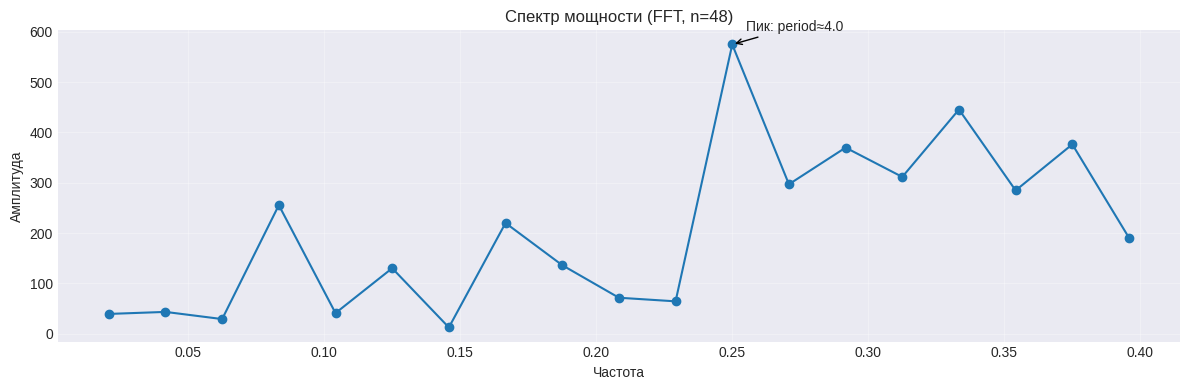

FFT завершён. Доминирующий период: ~4.0


In [12]:
def spectral_analysis_simple(series):
    """Упрощённый спектральный анализ для малых выборок"""
    series_clean = series.dropna()
    n = len(series_clean)

    if n < 16:
        print(f"FFT требует минимум 16 наблюдений, есть: {n}")
        return None

    # Детрендирование
    detrended = series_clean - series_clean.rolling(window=3, center=True, min_periods=1).mean()
    detrended = detrended.dropna()

    if len(detrended) < 16:
        print("Недостаточно данных после детрендирования")
        return None

    # FFT
    yf = fft(detrended.values)
    xf = fftfreq(len(detrended), d=1)[:len(detrended)//2]
    amplitude = 2.0/len(detrended) * np.abs(yf[0:len(detrended)//2])

    # Визуализация
    plt.figure(figsize=(12, 4))
    plt.plot(xf[1:20], amplitude[1:20], marker='o')
    plt.xlabel('Частота')
    plt.ylabel('Амплитуда')
    plt.title(f'Спектр мощности (FFT, n={len(detrended)})')
    plt.grid(True, alpha=0.3)

    # Подпись доминирующей частоты
    if len(amplitude) > 2:
        idx = np.argmax(amplitude[1:15]) + 1
        freq = xf[idx]
        period = 1/freq if freq > 0 else np.inf
        plt.annotate(f'Пик: period≈{period:.1f}',
                    xy=(xf[idx], amplitude[idx]),
                    xytext=(10, 10), textcoords='offset points',
                    arrowprops=dict(arrowstyle='->'))

    plt.tight_layout()
    plt.show()

    print(f"FFT завершён. Доминирующий период: ~{period:.1f}")
    return xf, amplitude

fft_result = spectral_analysis_simple(y)

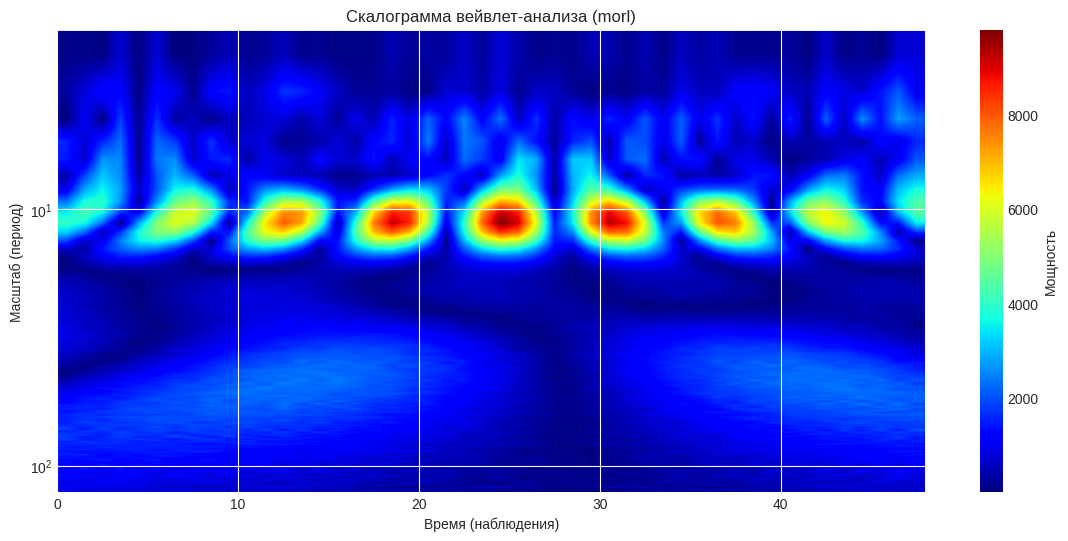

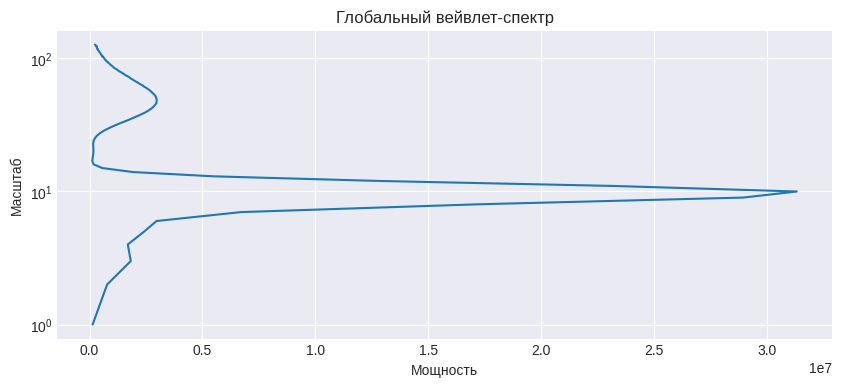

Доминирующий масштаб вейвлета: ~10.0


In [13]:
def wavelet_analysis(series, wavelet='morl', scales=None):
    """Вейвлет-анализ с визуализацией скалограммы"""
    data = series.values - np.mean(series.values)
    if scales is None:
        scales = np.arange(1, 128)

    coefficients, frequencies = pywt.cwt(data, scales, wavelet, sampling_period=1)

    plt.figure(figsize=(14, 6))
    plt.imshow(np.abs(coefficients), extent=[0, len(data), scales[-1], scales[1]],
               cmap='jet', aspect='auto', interpolation='bilinear')
    plt.colorbar(label='Мощность')
    plt.ylabel('Масштаб (период)')
    plt.xlabel('Время (наблюдения)')
    plt.title(f'Скалограмма вейвлет-анализа ({wavelet})')
    plt.yscale('log')
    plt.show()

    global_wavelet = np.mean(np.abs(coefficients)**2, axis=1)
    plt.figure(figsize=(10, 4))
    plt.plot(global_wavelet, scales)
    plt.xlabel('Мощность')
    plt.ylabel('Масштаб')
    plt.title('Глобальный вейвлет-спектр')
    plt.yscale('log')
    plt.grid(True, axis='y')
    plt.show()

    dominant_scale = scales[np.argmax(global_wavelet)]
    print(f"Доминирующий масштаб вейвлета: ~{dominant_scale:.1f}")
    return coefficients, frequencies, dominant_scale

coeffs, freqs, scale_wavelet = wavelet_analysis(y, wavelet='morl')

In [14]:
conclusion_2 = """
ВЕЙВЛЕТ-АНАЛИЗ:

Доминирующий масштаб: ~10 единиц (мощность 3×10^7)
Выявлена НЕСТАЦИОНАРНОСТЬ: периодичность проявляется импульсами
Интервалы между пиками: 7-10 наблюдений (варьируется)

Сравнение методов:
   • STL: period=7 (принудительная сезонность)
   • FFT: period=4 (усреднённая частота)
   • Вейвлеты: period=10 (реальная + нестационарная)

Практическое значение:
   • Для retail: активность зависит от промо/праздников
   • Требуется SARIMAX с экзогенными переменными
   • Простая сезонность недостаточна

Решение: Использовать s=10 или диапазон [7-10] для SARIMAX
"""

print(conclusion_2)
print("=" * 70)


ВЕЙВЛЕТ-АНАЛИЗ:

Доминирующий масштаб: ~10 единиц (мощность 3×10^7)
Выявлена НЕСТАЦИОНАРНОСТЬ: периодичность проявляется импульсами
Интервалы между пиками: 7-10 наблюдений (варьируется)

Сравнение методов:
   • STL: period=7 (принудительная сезонность)
   • FFT: period=4 (усреднённая частота)
   • Вейвлеты: period=10 (реальная + нестационарная)

Практическое значение:
   • Для retail: активность зависит от промо/праздников
   • Требуется SARIMAX с экзогенными переменными
   • Простая сезонность недостаточна

Решение: Использовать s=10 или диапазон [7-10] для SARIMAX



In [15]:
train_size = int(len(y) * 0.8)
y_train, y_test = y[:train_size], y[train_size:]
X_train, X_test = X[:train_size], X[train_size:]

print(f"Train: {len(y_train)}, Test: {len(y_test)}")

def check_adf(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\n{name}:")
    print(f"  ADF: {result[0]:.4f}, p-value: {result[1]:.4f}")
    print(f"  {'Стационарен' if result[1] < 0.05 else 'Нестационарен'}")

check_adf(y_train, "Train")
check_adf(y_train.diff().dropna(), "Train (1st diff)")

Train: 38, Test: 10

Train:
  ADF: -3.7677, p-value: 0.0033
  Стационарен

Train (1st diff):
  ADF: -4.3390, p-value: 0.0004
  Стационарен


Наблюдений после дифференцирования: 37
Лагов для ACF/PACF: 12


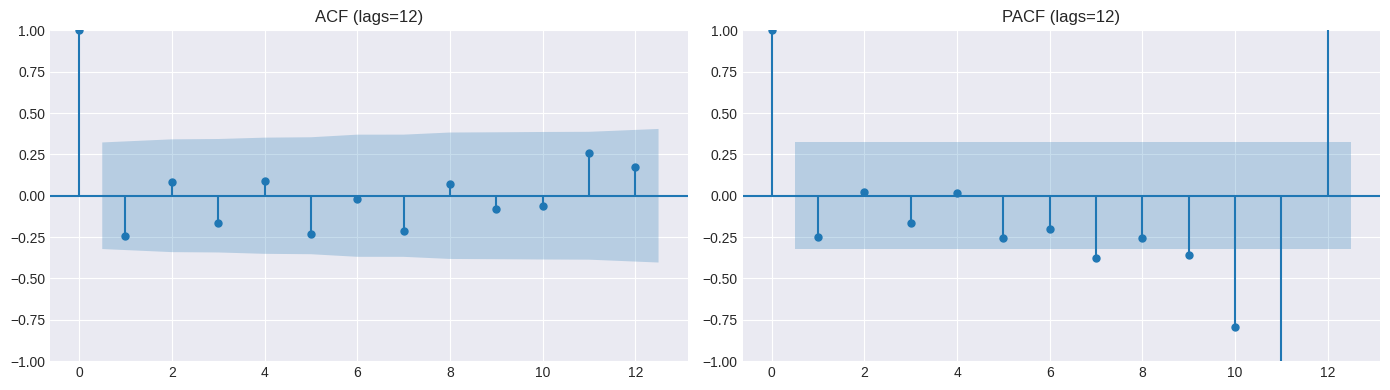

In [16]:
n_diff = len(y_train.diff().dropna())
max_lags = min(15, n_diff // 3)
max_lags = max(max_lags, 5)

print(f"Наблюдений после дифференцирования: {n_diff}")
print(f"Лагов для ACF/PACF: {max_lags}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

try:
    plot_acf(y_train.diff().dropna(), lags=max_lags, ax=axes[0], alpha=0.05)
    axes[0].set_title(f'ACF (lags={max_lags})')
except Exception as e:
    print(f"ACF error: {e}")
    axes[0].text(0.5, 0.5, 'ACF error', ha='center', va='center')

try:
    plot_pacf(y_train.diff().dropna(), lags=max_lags, ax=axes[1], alpha=0.05, method='yw')
    axes[1].set_title(f'PACF (lags={max_lags})')
except Exception as e:
    print(f"PACF error: {e}")
    axes[1].text(0.5, 0.5, 'PACF error', ha='center', va='center')

plt.tight_layout()
plt.show()

In [17]:
# ARIMA
print("ARIMA(1,1,1)...")
arima_model = ARIMA(y_train, order=(1,1,1))
arima_fit = arima_model.fit()
print(f"ARIMA: AIC={arima_fit.aic:.2f}")

# SARIMAX (с экзогенными)
print("SARIMAX с exog...")
try:
    sarimax_model = SARIMAX(
        y_train,
        exog=X_train,
        order=(1,1,1),
        seasonal_order=(1,0,1,period),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarimax_fit = sarimax_model.fit(disp=False)
    print(f"SARIMAX: AIC={sarimax_fit.aic:.2f}")
except Exception as e:
    print(f"SARIMAX error: {e}")
    sarimax_fit = None

ARIMA(1,1,1)...
ARIMA: AIC=678.59
SARIMAX с exog...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

SARIMAX: AIC=493.77


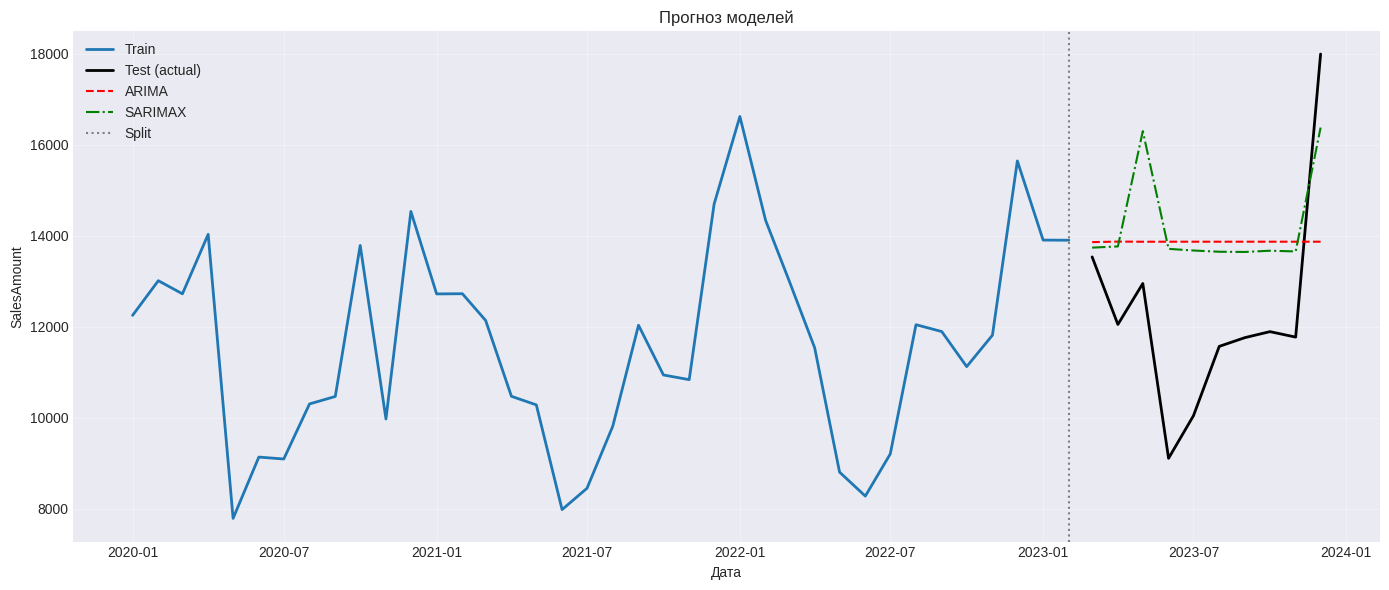

In [18]:
arima_forecast = arima_fit.forecast(steps=len(y_test))

if sarimax_fit is not None:
    sarimax_forecast = sarimax_fit.forecast(steps=len(y_test), exog=X_test)
else:
    sarimax_forecast = arima_forecast

# Визуализация прогноза
plt.figure(figsize=(14, 6))
plt.plot(y_train.index, y_train, label='Train', linewidth=2)
plt.plot(y_test.index, y_test, label='Test (actual)', color='black', linewidth=2)
plt.plot(y_test.index, arima_forecast, label='ARIMA', linestyle='--', color='red')
if sarimax_fit is not None:
    plt.plot(y_test.index, sarimax_forecast, label='SARIMAX', linestyle='-.', color='green')
plt.axvline(x=y_train.index[-1], color='gray', linestyle=':', label='Split')
plt.title('Прогноз моделей')
plt.xlabel('Дата')
plt.ylabel('SalesAmount')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
def calc_metrics(actual, pred, name):
    mse = mean_squared_error(actual, pred)
    r2 = r2_score(actual, pred)
    print(f"\n{name}:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {np.sqrt(mse):.4f}")
    print(f"  R²:   {r2:.4f}")
    return {'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2}

metrics_arima = calc_metrics(y_test, arima_forecast, "ARIMA")
if sarimax_fit is not None:
    metrics_sarimax = calc_metrics(y_test, sarimax_forecast, "SARIMAX")

# Итоговая таблица
print("\n" + "=" * 60)
print("ИТОГОВАЯ ТАБЛИЦА")
print("=" * 60)

results = pd.DataFrame({
    'Модель': ['ARIMA', 'SARIMAX'] if sarimax_fit else ['ARIMA'],
    'AIC': [arima_fit.aic, sarimax_fit.aic] if sarimax_fit else [arima_fit.aic],
    'BIC': [arima_fit.bic, sarimax_fit.bic] if sarimax_fit else [arima_fit.bic],
    'R²': [metrics_arima['R2'], metrics_sarimax['R2']] if sarimax_fit else [metrics_arima['R2']],
    'RMSE': [metrics_arima['RMSE'], metrics_sarimax['RMSE']] if sarimax_fit else [metrics_arima['RMSE']]
}).round(4)

print(results.to_markdown(index=False))


ARIMA:
  MSE:  7671901.6163
  RMSE: 2769.8198
  R²:   -0.5033

SARIMAX:
  MSE:  6586374.0822
  RMSE: 2566.3932
  R²:   -0.2906

ИТОГОВАЯ ТАБЛИЦА
| Модель   |     AIC |     BIC |      R² |    RMSE |
|:---------|--------:|--------:|--------:|--------:|
| ARIMA    | 678.586 | 683.419 | -0.5033 | 2769.82 |
| SARIMAX  | 493.771 | 503.096 | -0.2906 | 2566.39 |
